Building HOG features...
Processed 1/31780 images
Processed 100/31780 images
Processed 200/31780 images
Processed 300/31780 images
Processed 400/31780 images
Processed 500/31780 images
Processed 600/31780 images
Processed 700/31780 images
Processed 800/31780 images
Processed 900/31780 images
Processed 1000/31780 images
Processed 1100/31780 images
Processed 1200/31780 images
Processed 1300/31780 images
Processed 1400/31780 images
Processed 1500/31780 images
Processed 1600/31780 images
Processed 1700/31780 images
Processed 1800/31780 images
Processed 1900/31780 images
Processed 2000/31780 images
Processed 2100/31780 images
Processed 2200/31780 images
Processed 2300/31780 images
Processed 2400/31780 images
Processed 2500/31780 images
Processed 2600/31780 images
Processed 2700/31780 images
Processed 2800/31780 images
Processed 2900/31780 images
Processed 3000/31780 images
Processed 3100/31780 images
Processed 3200/31780 images
Processed 3300/31780 images
Processed 3400/31780 images
Process

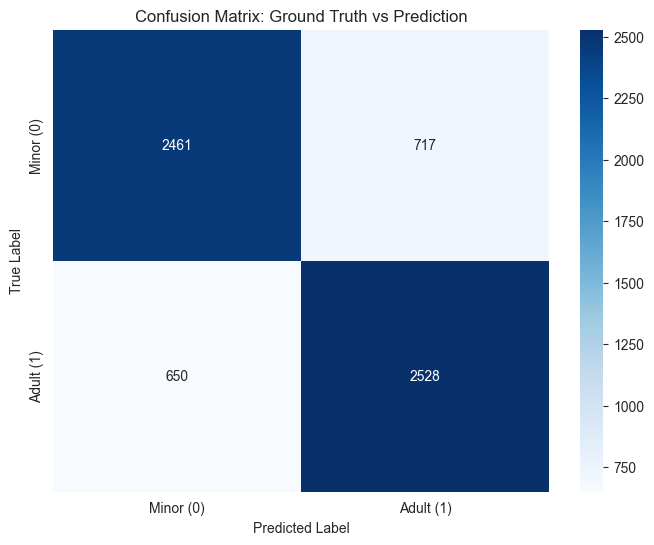

In [1]:
import json
import pickle
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from skimage.feature import hog
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

try:
    import joblib
except ImportError:
    joblib = None


PROJECT_ROOT = next(
    (
        candidate
        for candidate in [Path.cwd(), *Path.cwd().parents]
        if (candidate / 'data').exists() and (candidate / 'Model').exists()
    ),
    Path.cwd(),
)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

CONFIG = {
    'dataset_root': str(PROJECT_ROOT / 'data' / 'Face_Age_Dataset'),
    'out_dir': str(PROJECT_ROOT / 'Model' / 'HOG_SVM' / 'runs' / 'hog_svm_adult_binary'),
    'adult_age': 21,
    'image_size': 64,
    'orientations': 9,
    'pixels_per_cell': (8, 8),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys',
    'test_size': 0.2,
    'random_state': 42,
    'svm_c': 1.0,
    'max_iter': 5000,
    'dual': False,
    'decision_threshold': 0.0,
}


def parse_age_from_name(path: Path) -> int:
    stem = path.stem
    if '_' not in stem:
        raise ValueError(f"Filename does not contain '_' age separator: {path.name}")
    age_str = stem.rsplit('_', 1)[1]
    if not age_str.isdigit():
        raise ValueError(f"Age is not numeric in filename: {path.name}")
    return int(age_str)


def build_samples(root: Path):
    samples = []
    for path in root.rglob('*'):
        if path.is_file() and path.suffix.lower() in IMG_EXTS:
            age = parse_age_from_name(path)
            samples.append((path, age))
    if not samples:
        raise RuntimeError(f'No images found under {root}')
    return samples


def compute_hog_feature(image_path: Path, config):
    image = cv2.imread(str(image_path))
    if image is None:
        raise RuntimeError(f'Failed to read image: {image_path}')

    image_size = int(config['image_size'])
    gray = cv2.cvtColor(cv2.resize(image, (image_size, image_size)), cv2.COLOR_BGR2GRAY)

    feature = hog(
        gray,
        orientations=int(config['orientations']),
        pixels_per_cell=tuple(config['pixels_per_cell']),
        cells_per_block=tuple(config['cells_per_block']),
        block_norm=config['block_norm'],
    )
    return np.asarray(feature, dtype=np.float32)


def compute_metrics(y_true, y_pred):
    tp = fp = tn = fn = 0
    for true_label, pred_label in zip(y_true, y_pred):
        if pred_label == 1 and true_label == 1:
            tp += 1
        elif pred_label == 1 and true_label == 0:
            fp += 1
        elif pred_label == 0 and true_label == 0:
            tn += 1
        else:
            fn += 1

    total = len(y_true)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = (2 * precision * recall) / max(precision + recall, 1e-12)
    accuracy = (tp + tn) / max(total, 1)

    return {
        'total': int(total),
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'tp': int(tp),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
    }


dataset_root = Path(CONFIG['dataset_root'])
out_dir = Path(CONFIG['out_dir'])
out_dir.mkdir(parents=True, exist_ok=True)

samples = build_samples(dataset_root)

X = []
y = []

print('Building HOG features...')

for index, (img_path, age) in enumerate(samples, start=1):
    feature = compute_hog_feature(img_path, CONFIG)
    X.append(feature)
    y.append(1 if age >= CONFIG['adult_age'] else 0)

    if index == 1 or index % 100 == 0 or index == len(samples):
        print(f'Processed {index}/{len(samples)} images')

X = np.asarray(X, dtype=np.float32)
y = np.asarray(y, dtype=np.int64)

print('Finished feature extraction.')
print('Starting SVM training...')
print('Dataset root:', dataset_root)
print('Total images:', len(X))
print('Minor count:', int(np.sum(y == 0)))
print('Adult count:', int(np.sum(y == 1)))
print('Minor percentage:', float(np.sum(y == 0) / len(y) * 100))
print('Adult percentage:', float(np.sum(y == 1) / len(y) * 100))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state'],
    stratify=y,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearSVC(
    C=CONFIG['svm_c'],
    max_iter=CONFIG['max_iter'],
    dual=CONFIG['dual'],
    verbose=1,
)

model.fit(X_train, y_train)
pred = model.predict(X_test)
metrics = compute_metrics(y_test.tolist(), pred.tolist())
report = classification_report(y_test, pred, target_names=['minor', 'adult'])
cm = confusion_matrix(y_test, pred)

artifact_stem = 'best_hog_svm'
artifact_ext = '.joblib' if joblib is not None else '.pkl'
artifact_path = out_dir / f'{artifact_stem}{artifact_ext}'
bundle = {
    'model': model,
    'scaler': scaler,
    'config': {
        'adult_age': CONFIG['adult_age'],
        'image_size': CONFIG['image_size'],
        'orientations': CONFIG['orientations'],
        'pixels_per_cell': list(CONFIG['pixels_per_cell']),
        'cells_per_block': list(CONFIG['cells_per_block']),
        'block_norm': CONFIG['block_norm'],
        'decision_threshold': CONFIG['decision_threshold'],
    },
}

if joblib is not None:
    joblib.dump(bundle, artifact_path)
else:
    with artifact_path.open('wb') as file:
        pickle.dump(bundle, file)

with (out_dir / 'config.json').open('w', encoding='utf-8') as file:
    json.dump(CONFIG, file, indent=2)

with (out_dir / 'train_metrics.json').open('w', encoding='utf-8') as file:
    json.dump(metrics, file, indent=2)

with (out_dir / 'classification_report.txt').open('w', encoding='utf-8') as file:
    file.write(report)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))
print('Accuracy:', accuracy_score(y_test, pred))
print('Artifact:', artifact_path)
print('Config JSON:', out_dir / 'config.json')
print('Metrics JSON:', out_dir / 'train_metrics.json')
print('Report TXT:', out_dir / 'classification_report.txt')

print('\nConfusion Matrix:')
print(cm)

print('\nClassification Report:')
print(report)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Minor (0)', 'Adult (1)'],
    yticklabels=['Minor (0)', 'Adult (1)'],
)
plt.title('Confusion Matrix: Ground Truth vs Prediction')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
